# SAM 3 automatic mask generation on clean grain images

This notebook runs **Meta's Segment Anything Model 3 (SAM 3)** on clean (etched, high-contrast)
grain images using **only the built-in automatic mask generator** — no point/box/text prompts,
no `segmenteverygrain` U-Net seeding, no DBSCAN prompt generation. It is a baseline to see how
well an off-the-shelf, class-agnostic model segments grains with zero task-specific tuning.

SAM 3 is served through the Hugging Face `transformers` `mask-generation` pipeline
(`facebook/sam3`). Automatic mode tiles a grid of points over the whole image, predicts a mask
at every point, then de-duplicates and quality-filters them. It is memory intensive, so start
with a single image before batching.

**References**
- SAM 3: Segment Anything with Concepts — https://ai.meta.com/research/publications/sam-3-segment-anything-with-concepts/
- Model card: https://huggingface.co/facebook/sam3
- Docs: https://huggingface.co/docs/transformers/en/model_doc/sam3_tracker

## 1. Setup

SAM 3 requires a recent `transformers` (>= 5.12). Uncomment and run once if needed. The model
weights are gated on the Hub — you must accept the license at https://huggingface.co/facebook/sam3
and be logged in (`huggingface-cli login`) the first time you download them.

In [9]:
# !pip install -U "transformers>=5.12" torch torchvision pillow matplotlib numpy
# !huggingface-cli login

In [1]:
import glob
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from transformers import pipeline

# Pick the best available device: CUDA GPU, Apple Silicon (MPS), or CPU.
if torch.cuda.is_available():
    device = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

/Users/Alexander/miniforge3/envs/segmenteverygrain_new_SAM/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## 2. Load the SAM 3 automatic mask generator

The `mask-generation` pipeline wraps SAM 3's automatic (prompt-free) mode. This downloads the
weights on first run and caches them under `~/.cache/huggingface`.

In [2]:
generator = pipeline("mask-generation", model="facebook/sam3", device=device)
print("SAM 3 automatic mask generator ready.")

Loading weights: 100%|██████████| 685/685 [00:00<00:00, 10154.77it/s]


SAM 3 automatic mask generator ready.


## 3. Choose a clean grain image

Defaults to the held-out clean test image. Point `IMAGE_PATH` at any of the clean-image folders
(`testcleanimages/`, `real_clean_images/`, `test_only_clean_images/`). SAM expects RGB, so
grayscale SEM tiffs are converted with `.convert("RGB")`.

Loaded /Users/Alexander/Repositories/segmenteverygrain/testnoisyimages/cropped_Wilson180_0.25__surface1_03.tif  size=(1024, 703)  shape=(703, 1024, 3)


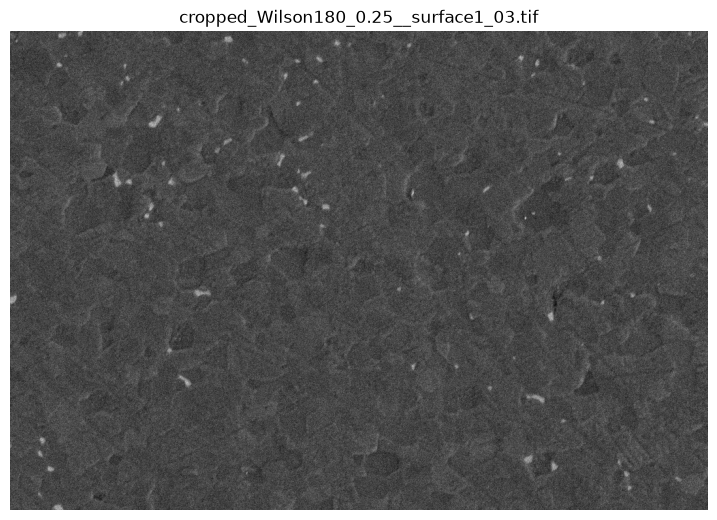

In [10]:
IMAGE_PATH = "/Users/Alexander/Repositories/segmenteverygrain/testnoisyimages/cropped_Wilson180_0.25__surface1_03.tif"

image = Image.open(IMAGE_PATH).convert("RGB")
image_np = np.array(image)
print(f"Loaded {IMAGE_PATH}  size={image.size}  shape={image_np.shape}")

plt.figure(figsize=(9, 9))
plt.imshow(image_np)
plt.title(os.path.basename(IMAGE_PATH))
plt.axis("off")
plt.show()

## 4. Run automatic mask generation

`points_per_batch` trades speed for memory (lower it if you hit OOM). The pipeline returns a dict
with `masks` (a list of boolean H×W arrays, one per detected object) and `scores` (per-mask
predicted IoU / quality). No prompts are provided — this is fully automatic.

In [11]:
outputs = generator(image, points_per_batch=64)

masks = outputs["masks"]          # list of bool arrays, shape (H, W)
scores = np.asarray(outputs["scores"])
print(f"SAM 3 generated {len(masks)} masks.")
print(f"Score range: {scores.min():.3f} – {scores.max():.3f}")

SAM 3 generated 0 masks.


ValueError: zero-size array to reduction operation minimum which has no identity

## 5. Visualize the masks

Each detected grain is drawn as a random translucent color over the original image.

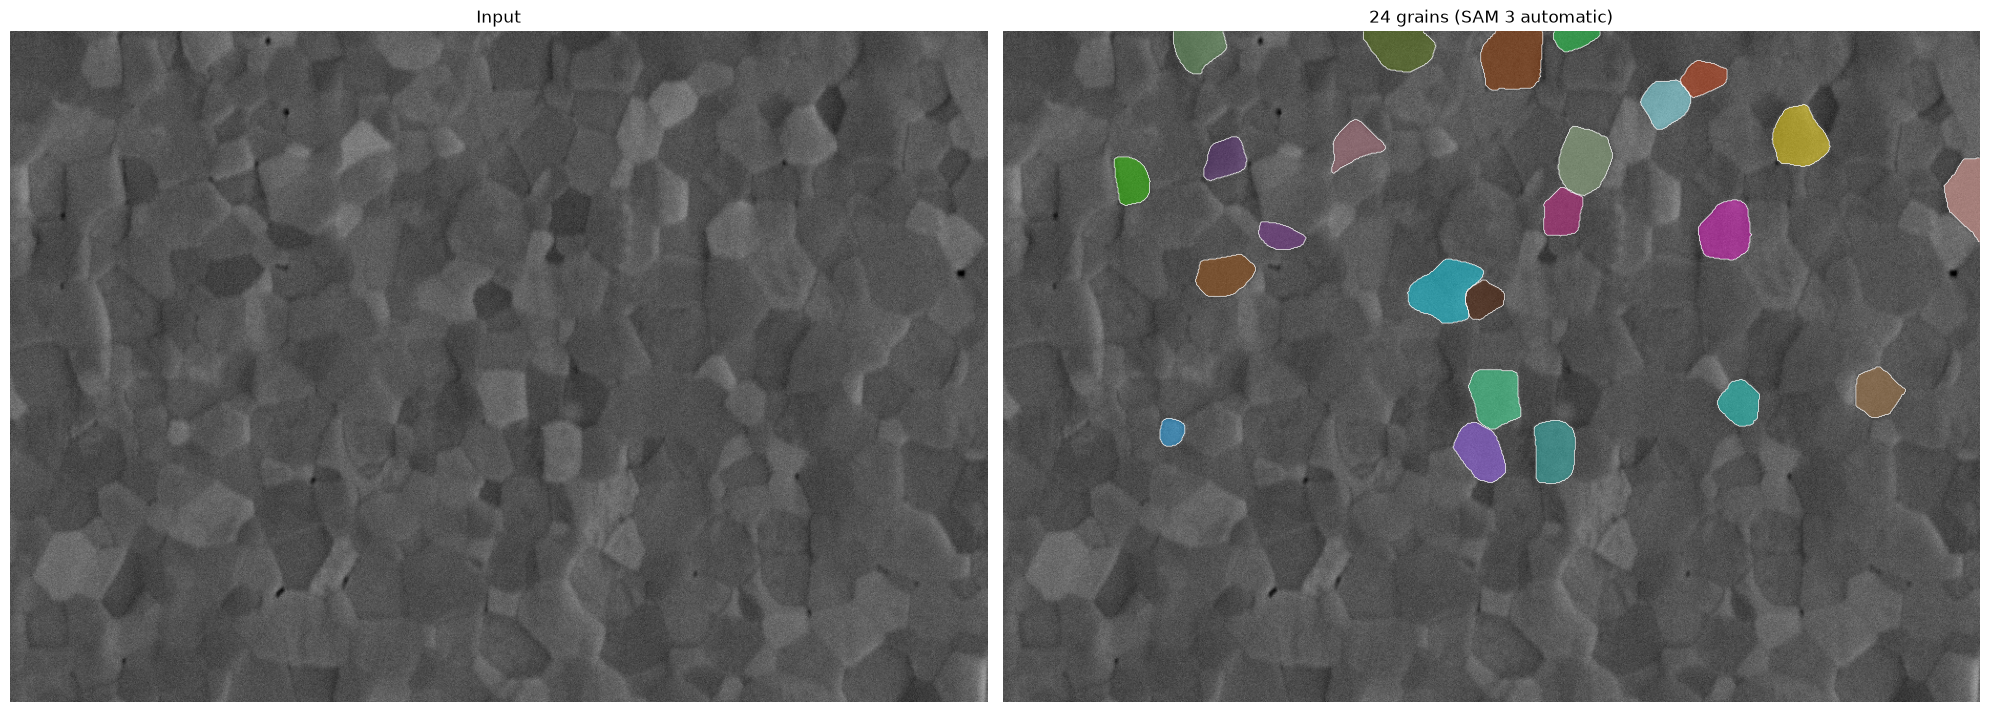

In [ ]:
def show_masks(image_np, masks, ax=None, alpha=0.5, draw_boundaries=True):
    """Overlay a list of boolean masks on an image with random colors."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image_np)
    if len(masks) == 0:
        ax.set_title("No masks")
        ax.axis("off")
        return ax

    h, w = np.asarray(masks[0]).shape
    overlay = np.zeros((h, w, 4), dtype=float)
    rng = np.random.default_rng(0)
    # Draw largest masks first so small grains stay visible on top.
    for m in sorted(masks, key=lambda x: np.asarray(x).sum(), reverse=True):
        m = np.asarray(m, dtype=bool)
        color = np.concatenate([rng.random(3), [alpha]])
        overlay[m] = color
    ax.imshow(overlay)

    if draw_boundaries:
        for m in masks:
            ax.contour(np.asarray(m, dtype=float), levels=[0.5], colors="white", linewidths=0.5)

    ax.set_title(f"{len(masks)} grains (SAM 3 automatic)")
    ax.axis("off")
    return ax


fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(image_np)
axes[0].set_title("Input")
axes[0].axis("off")
show_masks(image_np, masks, ax=axes[1])
plt.tight_layout()
plt.show()

## 6. Basic grain statistics

Class-agnostic pixel-area measurements (no calibration to microns). Areas are in pixels;
equivalent diameter is the diameter of a circle with the same area.

Grains detected : 24
Area  (px)      : min 613, median 1906, max 3539
Equiv. diam (px): min 27.9, median 49.3, max 67.1


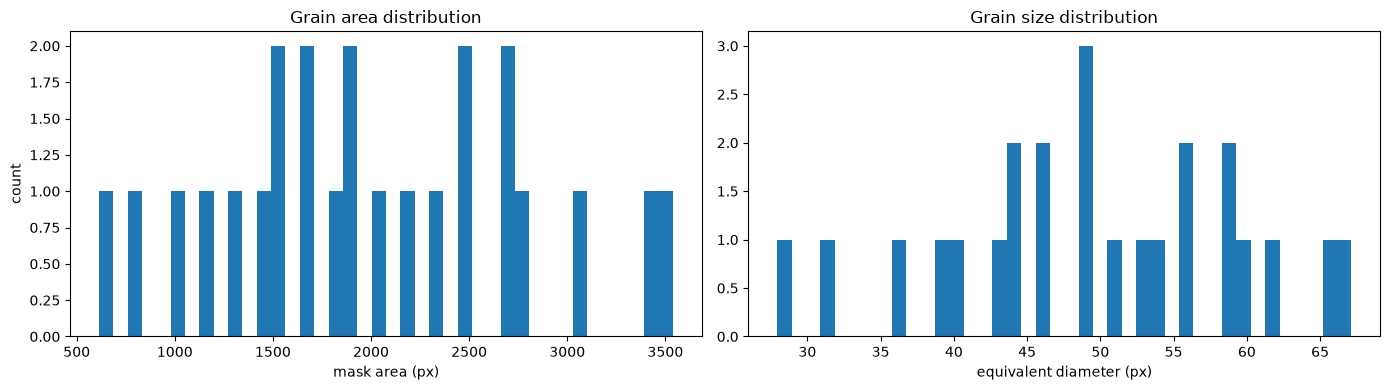

In [ ]:
areas = np.array([int(np.asarray(m).sum()) for m in masks])
equiv_diam = np.sqrt(4.0 * areas / np.pi)

print(f"Grains detected : {len(areas)}")
if len(areas):
    print(f"Area  (px)      : min {areas.min()}, median {int(np.median(areas))}, max {areas.max()}")
    print(f"Equiv. diam (px): min {equiv_diam.min():.1f}, median {np.median(equiv_diam):.1f}, max {equiv_diam.max():.1f}")

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].hist(areas, bins=40)
    ax[0].set_xlabel("mask area (px)")
    ax[0].set_ylabel("count")
    ax[0].set_title("Grain area distribution")
    ax[1].hist(equiv_diam, bins=40)
    ax[1].set_xlabel("equivalent diameter (px)")
    ax[1].set_title("Grain size distribution")
    plt.tight_layout()
    plt.show()

Aggressive whole-image run: 68 grains (defaults gave 0)


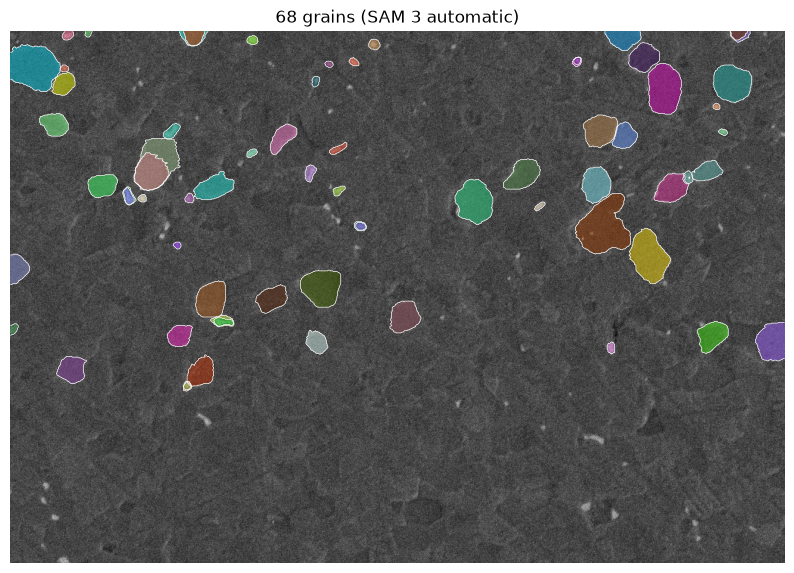

In [12]:
# ---- SAM 3 automatic-mask-generator knobs (all exposed) ----
# Recall goes up when you sample more points and relax the quality gates.
POINTS_PER_CROP         = 64    # grid density per (tile) image; biggest recall lever   (default 32)
POINTS_PER_BATCH        = 64    # points scored per forward pass; memory/speed only      (default 64)
PRED_IOU_THRESH         = 0.70  # drop masks below this predicted IoU; lower = more      (default 0.88)
STABILITY_SCORE_THRESH  = 0.88  # drop masks below this stability score; lower = more    (default 0.95)
STABILITY_SCORE_OFFSET  = 1.0   # offset used when computing the stability score         (default 1.0)
MASK_THRESHOLD          = 0.0   # logit threshold for binarizing masks                   (default 0.0)
CROPS_N_LAYERS          = 0     # SAM's own zoom-in crop layers; leave 0 when tiling      (default 0)
CROP_N_POINTS_DOWNSCALE = 2     # divide points_per_crop by this on each crop layer       (default 1)
CROP_OVERLAP_RATIO      = 0.34  # fractional overlap between SAM's internal crops         (default ~0.34)
CROPS_NMS_THRESH        = 0.70  # NMS IoU across crop results; higher = keep more overlap (default 0.7)

SAM3_KWARGS = dict(
    points_per_batch=POINTS_PER_BATCH,
    points_per_crop=POINTS_PER_CROP,
    pred_iou_thresh=PRED_IOU_THRESH,
    stability_score_thresh=STABILITY_SCORE_THRESH,
    stability_score_offset=STABILITY_SCORE_OFFSET,
    mask_threshold=MASK_THRESHOLD,
    crops_n_layers=CROPS_N_LAYERS,
    crop_n_points_downscale_factor=CROP_N_POINTS_DOWNSCALE,
    crop_overlap_ratio=CROP_OVERLAP_RATIO,
    crops_nms_thresh=CROPS_NMS_THRESH,
)


def run_sam3(img, **overrides):
    """Run SAM 3 automatic mask generation with the knobs above (override any per call)."""
    out = generator(img, **{**SAM3_KWARGS, **overrides})
    return out["masks"], np.asarray(out["scores"])


# Whole-image run with the aggressive settings (SAM still downscales to ~1008 px internally):
masks_aggr, scores_aggr = run_sam3(image)
print(f"Aggressive whole-image run: {len(masks_aggr)} grains (defaults gave {len(masks)})")
show_masks(image_np, masks_aggr)
plt.show()

## 8. Tiled segmentation — avoid SAM's internal downscaling

SAM 3 resizes the whole image to ~1008 px before it samples points, so in a large SEM image the
smaller grains are gone before segmentation even starts. Splitting the image into **overlapping
tiles that are each ≤ ~1008 px** keeps every tile at native resolution, so SAM sees fine grains
clearly. This is the same idea as `crops_n_layers`, but done explicitly so you control tile size
and overlap.

`segment_tiled` below:
1. cuts the image into overlapping tiles (`TILE_SIZE`, `OVERLAP`),
2. runs `run_sam3` on each tile with the knobs from section 7,
3. drops masks touching an *interior* tile edge (partial grains — the overlap ensures a neighbor
   tile holds the whole grain), and
4. merges everything with NMS (`NMS_IOU`) to remove duplicates in the overlap zones.

Set `OVERLAP` larger than your biggest grain so nothing is lost at a seam. Note this holds every
mask as a full-image boolean array, so very large images × many grains use a lot of RAM — reduce
`TILE_SIZE`/increase step, or downcast, if memory is tight.

In [8]:
def _bbox(m):
    ys, xs = np.where(m)
    return xs.min(), ys.min(), xs.max() + 1, ys.max() + 1


def _bbox_overlap(a, b):
    return not (a[2] <= b[0] or b[2] <= a[0] or a[3] <= b[1] or b[3] <= a[1])


def _iou(a, b):
    inter = np.count_nonzero(a & b)
    if inter == 0:
        return 0.0
    return inter / np.count_nonzero(a | b)


def nms_masks(masks, scores, iou_thresh=0.7):
    """Greedy non-max suppression over boolean masks, highest score first."""
    if not masks:
        return [], np.array([])
    boxes = [_bbox(m) for m in masks]
    order = np.argsort(scores)[::-1]
    suppressed = np.zeros(len(masks), dtype=bool)
    keep = []
    for i in order:
        if suppressed[i]:
            continue
        keep.append(i)
        for j in order:
            if j == i or suppressed[j]:
                continue
            if _bbox_overlap(boxes[i], boxes[j]) and _iou(masks[i], masks[j]) > iou_thresh:
                suppressed[j] = True
    return [masks[i] for i in keep], scores[np.array(keep)]


def segment_tiled(image, tile_size=1000, overlap=250, nms_iou=0.7, **overrides):
    """Segment a large image tile-by-tile so SAM never downscales it.

    Each tile is <= tile_size (so no internal downscaling) and is segmented
    independently with `run_sam3`. Masks touching a tile edge that is *not* the
    image edge are dropped as partial grains -- the overlap guarantees the whole
    grain is captured by a neighboring tile -- then the survivors are merged with
    NMS to remove duplicates from the overlap regions.
    """
    image_np = np.asarray(image.convert("RGB")) if isinstance(image, Image.Image) else np.asarray(image)
    H, W = image_np.shape[:2]

    def origins(length, tile, step):
        if tile >= length:
            return [0]
        pts = list(range(0, length - tile + 1, step))
        if pts[-1] != length - tile:
            pts.append(length - tile)  # clamp the last tile flush to the edge
        return pts

    th, tw = min(tile_size, H), min(tile_size, W)
    ys, xs = origins(H, th, th - overlap), origins(W, tw, tw - overlap)

    all_masks, all_scores = [], []
    for y0 in ys:
        for x0 in xs:
            tile = image_np[y0:y0 + th, x0:x0 + tw]
            m_list, s_list = run_sam3(Image.fromarray(tile), **overrides)
            for m, s in zip(m_list, s_list):
                m = np.asarray(m, dtype=bool)
                touches_interior_edge = (
                    (m[0, :].any() and y0 > 0)
                    or (m[-1, :].any() and y0 + th < H)
                    or (m[:, 0].any() and x0 > 0)
                    or (m[:, -1].any() and x0 + tw < W)
                )
                if touches_interior_edge:
                    continue
                full = np.zeros((H, W), dtype=bool)
                full[y0:y0 + th, x0:x0 + tw] = m
                all_masks.append(full)
                all_scores.append(float(s))

    print(f"  {len(ys)}x{len(xs)} tiles -> {len(all_masks)} masks before NMS")
    merged, merged_scores = nms_masks(all_masks, np.asarray(all_scores), iou_thresh=nms_iou)
    print(f"  -> {len(merged)} masks after NMS")
    return merged, merged_scores

  1x2 tiles -> 354 masks before NMS
  -> 191 masks after NMS

Tiled total : 191 grains
Whole-image : 176 grains (aggressive)
Defaults    : 24 grains


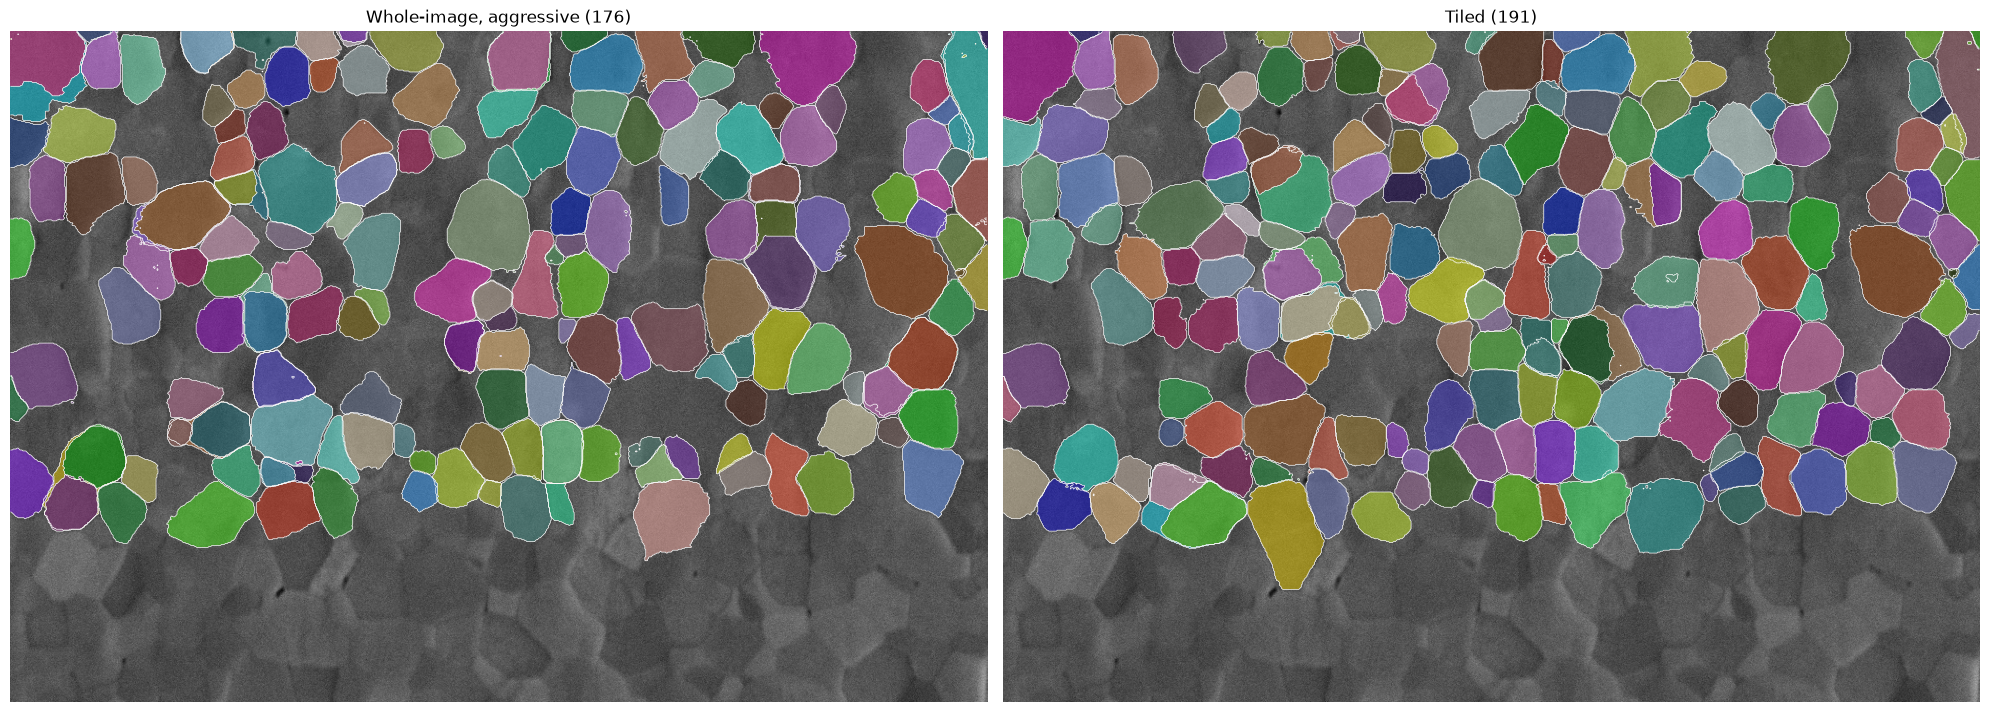

In [9]:
TILE_SIZE = 1000   # <= ~1008 keeps each tile at native resolution (no SAM downscaling)
OVERLAP   = 250    # should exceed the largest grain diameter so no grain is lost at a seam
NMS_IOU   = 0.7    # IoU above which two masks from overlapping tiles are treated as duplicates

masks_tiled, scores_tiled = segment_tiled(
    image, tile_size=TILE_SIZE, overlap=OVERLAP, nms_iou=NMS_IOU,
    crops_n_layers=0,  # tiling replaces SAM's internal cropping, so disable it here
)
print(f"\nTiled total : {len(masks_tiled)} grains")
print(f"Whole-image : {len(masks_aggr)} grains (aggressive)")
print(f"Defaults    : {len(masks)} grains")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
show_masks(image_np, masks_aggr, ax=axes[0])
axes[0].set_title(f"Whole-image, aggressive ({len(masks_aggr)})")
show_masks(image_np, masks_tiled, ax=axes[1])
axes[1].set_title(f"Tiled ({len(masks_tiled)})")
plt.tight_layout()
plt.show()

## 7. (Optional) Batch over a folder of clean images

Runs the same prompt-free segmentation across every image in a folder and saves an overlay PNG
plus the grain count for each. Set `SAVE_DIR` to keep the outputs.

In [ ]:
BATCH_DIR = "testcleanimages"
SAVE_DIR = "sam3_clean_grain_outputs"
MAX_IMAGES = 5  # set to None to process the whole folder

os.makedirs(SAVE_DIR, exist_ok=True)
paths = sorted(glob.glob(os.path.join(BATCH_DIR, "*.tif")))
if MAX_IMAGES is not None:
    paths = paths[:MAX_IMAGES]

results = {}
for p in paths:
    img = Image.open(p).convert("RGB")
    out = generator(img, points_per_batch=64)
    n = len(out["masks"])
    results[os.path.basename(p)] = n

    fig, ax = plt.subplots(figsize=(10, 10))
    show_masks(np.array(img), out["masks"], ax=ax)
    stem = os.path.splitext(os.path.basename(p))[0]
    fig.savefig(os.path.join(SAVE_DIR, f"{stem}_sam3_overlay.png"), bbox_inches="tight", dpi=150)
    plt.close(fig)
    print(f"{os.path.basename(p)}: {n} grains")

print("\nGrain counts:", results)